# Stage 1: Directional Flow Mapping Tests

Test whether mapping performance depends on flow direction.

**Tests:**
- **Test A**: Horizontal Poiseuille flow (periodic channel, x-direction)
- **Test B**: Vertical channel flow (periodic channel, y-direction)
- **Test C**: Diagonal flow (periodic domain, 45° body force)

**Mappings compared:** snake, colmajor, hilbert, diagonal_tl, diagonal_tr

**Parameters:** Re=100, n=256, body_force=1e-5, steady-state analysis with cylinder obstacle

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from lbm import D2Q9, compute_equilibrium, stream, collide_bgk, apply_bounce_back, create_cylinder_mask
from lbm.collision import compute_moments
from tn.compression import compress_populations, decompress_populations, field_to_qtt
from tn.mapping import flatten_2d

# Velocity names for D2Q9
velocity_names = ['Rest', 'East', 'North', 'West', 'South', 'NE', 'NW', 'SW', 'SE']

## 1. Periodic Flow Simulation Function

In [24]:
def run_periodic_flow(n, Re, direction='horizontal', u_ref=0.1, nt=20000, 
                      convergence_threshold=1e-6, verbose=True):
    """
    Run periodic flow with body force and cylinder obstacle in center.
    
    Args:
        n: Grid size (n x n)
        Re: Reynolds number
        direction: 'horizontal', 'vertical', or 'diagonal'
        u_ref: Reference velocity for Re calculation
        nt: Maximum timesteps
        convergence_threshold: Stop when velocity change < threshold
        verbose: Print progress
    
    Returns:
        f: Final distribution function
        params: Simulation parameters
    """
    L = n
    nu = u_ref * L / Re
    tau = 3 * nu + 0.5
    
    if verbose:
        print(f"Direction: {direction}")
        print(f"n={n}, Re={Re}, tau={tau:.4f}")
    
    if tau <= 0.5:
        raise ValueError(f"tau={tau:.4f} <= 0.5, unstable!")
    
    # Create cylinder obstacle in center
    cx = cy = n // 2
    radius = n // 10  # 10% of domain size
    cylinder = create_cylinder_mask(n, n, cx, cy, radius)
    
    if verbose:
        print(f"Cylinder: center=({cx},{cy}), radius={radius}")
    
    # Initialize at rest
    rho = np.ones((n, n))
    u = np.zeros((2, n, n))
    f = compute_equilibrium(D2Q9, rho, u)
    
    # Body force direction
    if direction == 'horizontal':
        force = np.array([1e-5, 0.0])  # F_x only
    elif direction == 'vertical':
        force = np.array([0.0, 1e-5])  # F_y only
    elif direction == 'diagonal':
        f_mag = 1e-5 / np.sqrt(2)  # Equal components at 45°
        force = np.array([f_mag, f_mag])
    else:
        raise ValueError(f"Unknown direction: {direction}")
    
    # For convergence check
    u_prev = u.copy()
    converged = False
    final_t = nt
    
    for t in range(1, nt + 1):
        # Collision with body force (Guo forcing scheme)
        f = collide_bgk(D2Q9, f, tau)
        
        # Add body force (simple Shan-Chen style)
        for i in range(D2Q9.q):
            cu = D2Q9.c[i, 0] * force[0] + D2Q9.c[i, 1] * force[1]
            f[i] += D2Q9.w[i] * 3.0 * cu
        
        # Streaming (periodic BC automatic)
        f = stream(D2Q9, f)
        
        # Apply bounce-back on cylinder
        f = apply_bounce_back(D2Q9, f, cylinder)
        
        # Check convergence every 1000 steps
        if t % 1000 == 0:
            rho, u = compute_moments(D2Q9, f)
            
            # Zero velocity inside cylinder for visualization
            u[0, cylinder] = 0
            u[1, cylinder] = 0
            
            du = np.sqrt(np.sum((u - u_prev)**2) / np.sum(u_prev**2 + 1e-10))
            u_max = np.max(np.sqrt(u[0]**2 + u[1]**2))
            
            if verbose:
                print(f"  t={t}/{nt}, du={du:.2e}, u_max={u_max:.4f}")
            
            if du < convergence_threshold:
                if verbose:
                    print(f"  Converged at t={t}")
                converged = True
                final_t = t
                break
            
            u_prev = u.copy()
            
            # Stability check
            if np.any(np.isnan(rho)) or u_max > 0.5:
                print(f"  UNSTABLE at t={t}!")
                break
    
    if verbose and not converged:
        print(f"  Finished {nt} timesteps (not fully converged)")
    
    return f, {
        'n': n, 'Re': Re, 'tau': tau, 'nu': nu,
        'direction': direction, 'force': force,
        'cylinder': cylinder, 'cylinder_center': (cx, cy), 'cylinder_radius': radius,
        'converged': converged, 'final_t': final_t
    }

## 2. Run All Three Tests

In [25]:
n = 256
Re = 100  # Lower Re to get vortex shedding with cylinder obstacle

print("="*60)
print("Test A: Horizontal Flow")
print("="*60)
f_horizontal, params_horizontal = run_periodic_flow(n=n, Re=Re, direction='horizontal')
print()

print("="*60)
print("Test B: Vertical Flow")
print("="*60)
f_vertical, params_vertical = run_periodic_flow(n=n, Re=Re, direction='vertical')
print()

print("="*60)
print("Test C: Diagonal Flow")
print("="*60)
f_diagonal, params_diagonal = run_periodic_flow(n=n, Re=Re, direction='diagonal')
print()

# Store all data
all_tests = {
    'horizontal': (f_horizontal, params_horizontal),
    'vertical': (f_vertical, params_vertical),
    'diagonal': (f_diagonal, params_diagonal)
}

print("All simulations complete!")
print(f"f shape: {f_horizontal.shape} (9 populations, {n}x{n} grid)")

Test A: Horizontal Flow
Direction: horizontal
n=256, Re=100, tau=1.2680
Cylinder: center=(128,128), radius=25
  t=1000/20000, du=6.51e+02, u_max=0.0126
  t=2000/20000, du=9.45e-01, u_max=0.0238
  t=3000/20000, du=4.64e-01, u_max=0.0346
  t=4000/20000, du=3.03e-01, u_max=0.0449
  t=5000/20000, du=2.22e-01, u_max=0.0547
  t=6000/20000, du=1.73e-01, u_max=0.0637
  t=7000/20000, du=1.40e-01, u_max=0.0721
  t=8000/20000, du=1.16e-01, u_max=0.0809
  t=9000/20000, du=9.91e-02, u_max=0.0900
  t=10000/20000, du=8.59e-02, u_max=0.0986
  t=11000/20000, du=7.54e-02, u_max=0.1067
  t=12000/20000, du=6.67e-02, u_max=0.1145
  t=13000/20000, du=5.94e-02, u_max=0.1219
  t=14000/20000, du=5.33e-02, u_max=0.1290
  t=15000/20000, du=4.81e-02, u_max=0.1358
  t=16000/20000, du=4.37e-02, u_max=0.1422
  t=17000/20000, du=3.98e-02, u_max=0.1483
  t=18000/20000, du=3.63e-02, u_max=0.1541
  t=19000/20000, du=3.33e-02, u_max=0.1596
  t=20000/20000, du=3.06e-02, u_max=0.1648
  Finished 20000 timesteps (not fully c

## 3. Visualize Flow Fields

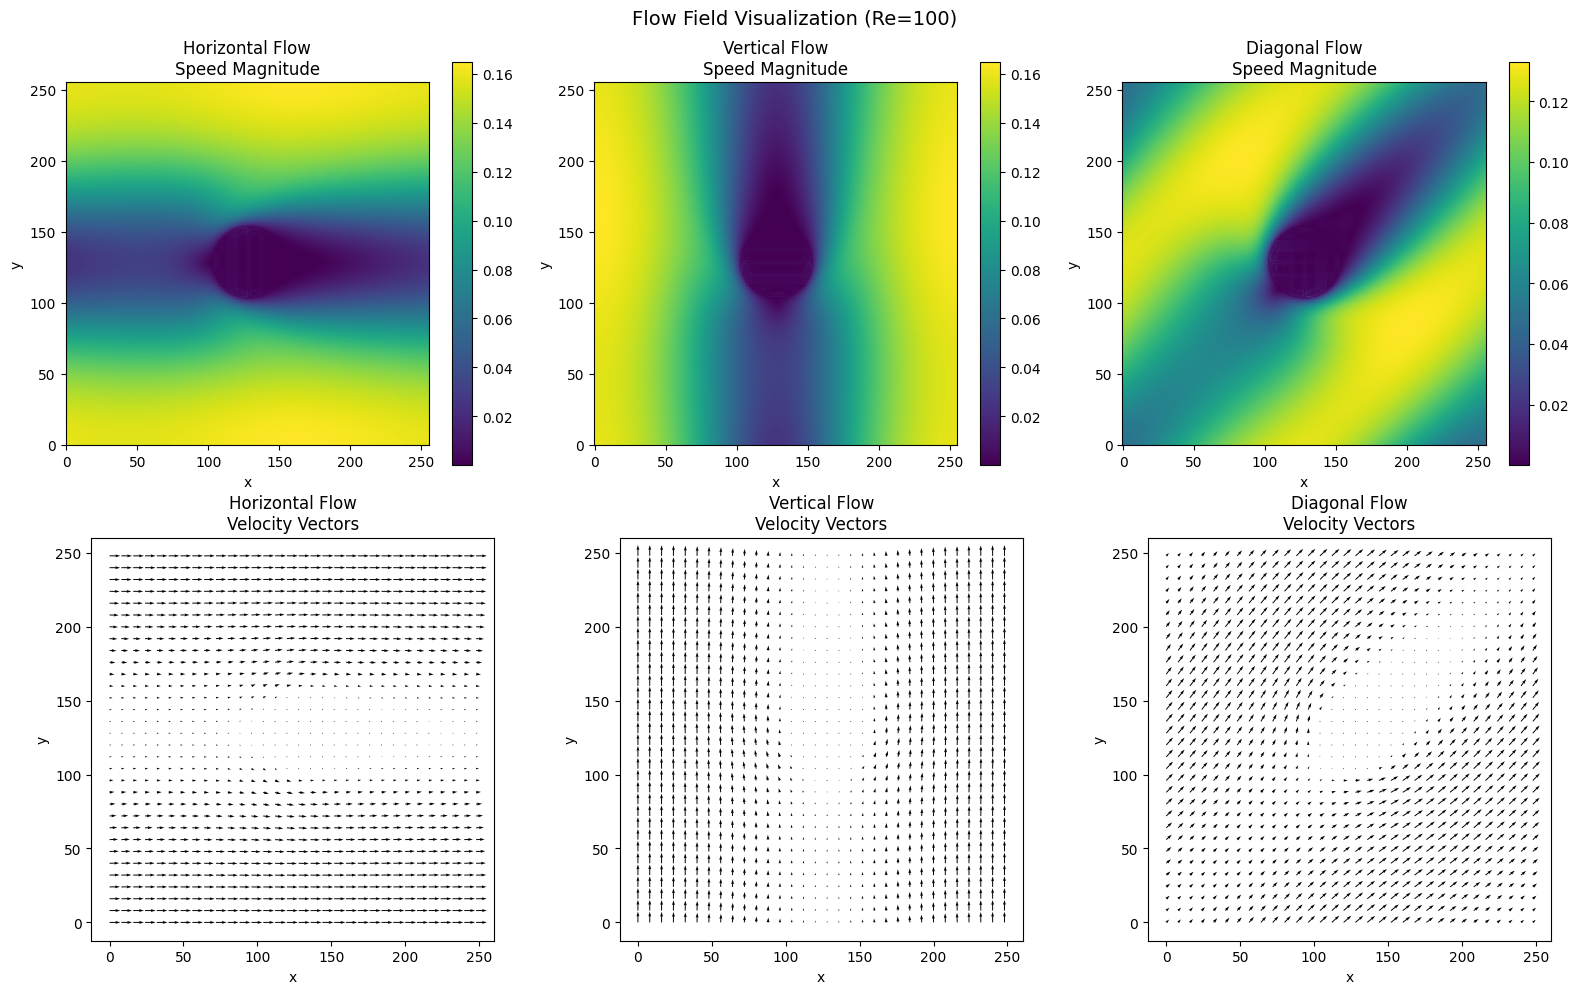

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, (test_name, (f_test, params)) in enumerate(all_tests.items()):
    rho, u = compute_moments(D2Q9, f_test)
    speed = np.sqrt(u[0]**2 + u[1]**2)
    
    # Top row: velocity magnitude
    im = axes[0, col].imshow(speed.T, cmap='viridis', origin='lower')
    axes[0, col].set_title(f'{test_name.capitalize()} Flow\nSpeed Magnitude', fontsize=12)
    axes[0, col].set_xlabel('x')
    axes[0, col].set_ylabel('y')
    plt.colorbar(im, ax=axes[0, col])
    
    # Bottom row: velocity vectors (subsampled)
    skip = 8
    x = np.arange(0, n, skip)
    y = np.arange(0, n, skip)
    X, Y = np.meshgrid(x, y)
    
    axes[1, col].quiver(X, Y, u[0, ::skip, ::skip].T, u[1, ::skip, ::skip].T)
    axes[1, col].set_title(f'{test_name.capitalize()} Flow\nVelocity Vectors', fontsize=12)
    axes[1, col].set_xlabel('x')
    axes[1, col].set_ylabel('y')
    axes[1, col].set_aspect('equal')

plt.suptitle(f'Flow Field Visualization (Re={Re})', fontsize=14, y=0.99)
plt.tight_layout()
plt.show()

## 4. Compression Analysis: Natural Bond Dimensions

In [27]:
# Mappings to test
mappings = ['snake', 'colmajor', 'hilbert', 'diagonal_tl', 'diagonal_tr']

# Compute natural bond dimensions for all tests and mappings
natural_bonds = {}  # (test_name, mapping) -> {'max': chi_max, 'mean': chi_mean}

print("Computing natural bond dimensions...\n")
for test_name, (f_test, params) in all_tests.items():
    print(f"{test_name.upper()}:")
    for mapping in mappings:
        mps_list, _ = compress_populations(f_test, max_bond=None, mapping=mapping)
        chi_max = max(mps.max_bond() for mps in mps_list)
        chi_mean = np.mean([mps.max_bond() for mps in mps_list])
        natural_bonds[(test_name, mapping)] = {'max': chi_max, 'mean': chi_mean}
        print(f"  {mapping:12s}: chi_max={chi_max:3d}, chi_mean={chi_mean:5.1f}")
    print()

Computing natural bond dimensions...

HORIZONTAL:
  snake       : chi_max= 56, chi_mean= 48.4
  colmajor    : chi_max= 56, chi_mean= 46.8
  hilbert     : chi_max= 43, chi_mean= 38.8
  diagonal_tl : chi_max=251, chi_mean=245.4
  diagonal_tr : chi_max=251, chi_mean=245.4

VERTICAL:
  snake       : chi_max= 56, chi_mean= 46.8
  colmajor    : chi_max= 56, chi_mean= 48.4
  hilbert     : chi_max= 43, chi_mean= 38.7
  diagonal_tl : chi_max=250, chi_mean=245.3
  diagonal_tr : chi_max=250, chi_mean=245.3

DIAGONAL:
  snake       : chi_max= 61, chi_mean= 52.9
  colmajor    : chi_max= 61, chi_mean= 52.9
  hilbert     : chi_max= 45, chi_mean= 41.2
  diagonal_tl : chi_max=244, chi_mean=226.1
  diagonal_tr : chi_max=246, chi_mean=228.6



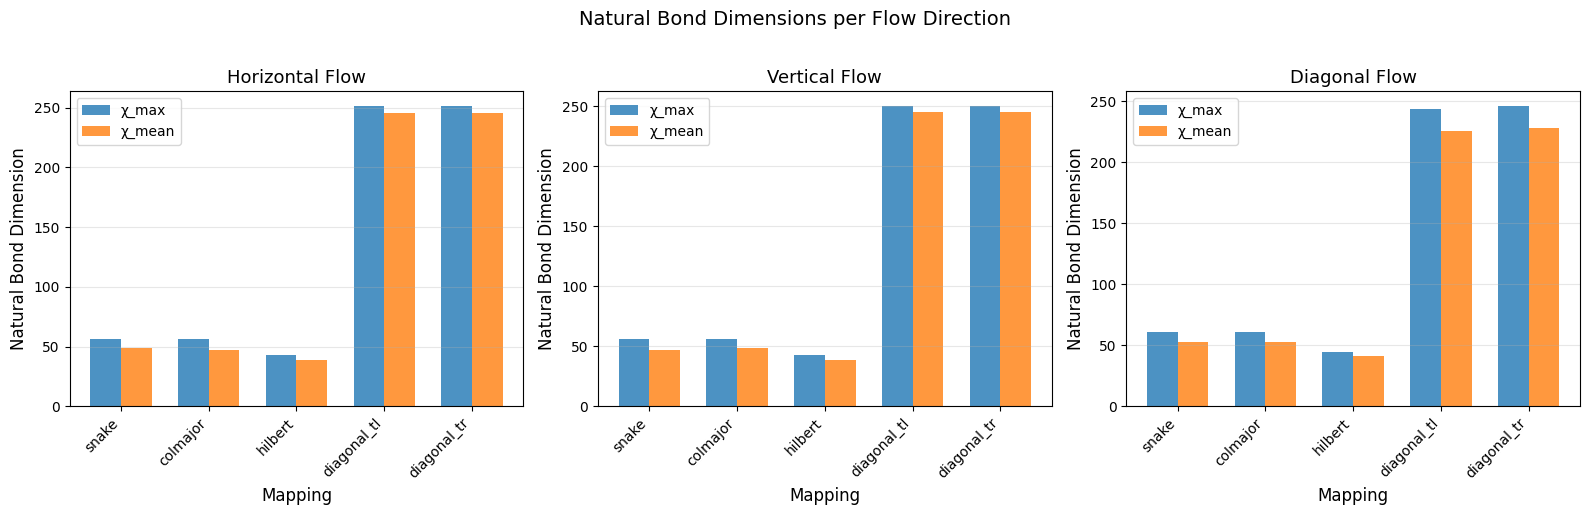

In [28]:
# Visualize natural bond dimensions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

test_names = ['horizontal', 'vertical', 'diagonal']
colors = {'snake': 'C0', 'colmajor': 'C1', 'hilbert': 'C2', 'diagonal_tl': 'C3', 'diagonal_tr': 'C4'}

for ax, test_name in zip(axes, test_names):
    chi_maxs = [natural_bonds[(test_name, m)]['max'] for m in mappings]
    chi_means = [natural_bonds[(test_name, m)]['mean'] for m in mappings]
    
    x = np.arange(len(mappings))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, chi_maxs, width, label='χ_max', alpha=0.8)
    bars2 = ax.bar(x + width/2, chi_means, width, label='χ_mean', alpha=0.8)
    
    ax.set_xlabel('Mapping', fontsize=12)
    ax.set_ylabel('Natural Bond Dimension', fontsize=12)
    ax.set_title(f'{test_name.capitalize()} Flow', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(mappings, rotation=45, ha='right')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Natural Bond Dimensions per Flow Direction', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Compression Error at Fixed χ

In [29]:
# Test compression error at chi=16
chi_fixed = 16
errors = {}  # (test_name, mapping) -> {'f_err': ..., 'u_err': ...}

print(f"Computing compression errors at chi={chi_fixed}...\n")
for test_name, (f_test, params) in all_tests.items():
    print(f"{test_name.upper()}:")
    rho_orig, u_orig = compute_moments(D2Q9, f_test)
    
    for mapping in mappings:
        mps_list, meta = compress_populations(f_test, max_bond=chi_fixed, mapping=mapping)
        f_recon = decompress_populations(mps_list, meta)
        rho_comp, u_comp = compute_moments(D2Q9, f_recon)
        
        f_err = np.linalg.norm(f_test - f_recon) / np.linalg.norm(f_test)
        u_err = np.linalg.norm(u_orig - u_comp) / np.linalg.norm(u_orig)
        
        errors[(test_name, mapping)] = {'f_err': f_err, 'u_err': u_err}
        print(f"  {mapping:12s}: f_err={f_err:.2e}, u_err={u_err:.2e}")
    print()

Computing compression errors at chi=16...

HORIZONTAL:
  snake       : f_err=3.28e-04, u_err=1.57e-03
  colmajor    : f_err=3.02e-04, u_err=1.47e-03
  hilbert     : f_err=3.59e-04, u_err=1.89e-03
  diagonal_tl : f_err=1.86e-02, u_err=1.47e-01
  diagonal_tr : f_err=1.86e-02, u_err=1.47e-01

VERTICAL:
  snake       : f_err=3.02e-04, u_err=1.47e-03
  colmajor    : f_err=3.28e-04, u_err=1.57e-03
  hilbert     : f_err=3.33e-04, u_err=1.73e-03
  diagonal_tl : f_err=1.90e-02, u_err=1.45e-01
  diagonal_tr : f_err=1.90e-02, u_err=1.44e-01

DIAGONAL:
  snake       : f_err=5.92e-04, u_err=2.76e-03
  colmajor    : f_err=5.92e-04, u_err=2.76e-03
  hilbert     : f_err=4.07e-04, u_err=2.59e-03
  diagonal_tl : f_err=1.64e-02, u_err=1.54e-01
  diagonal_tr : f_err=6.53e-03, u_err=5.26e-02



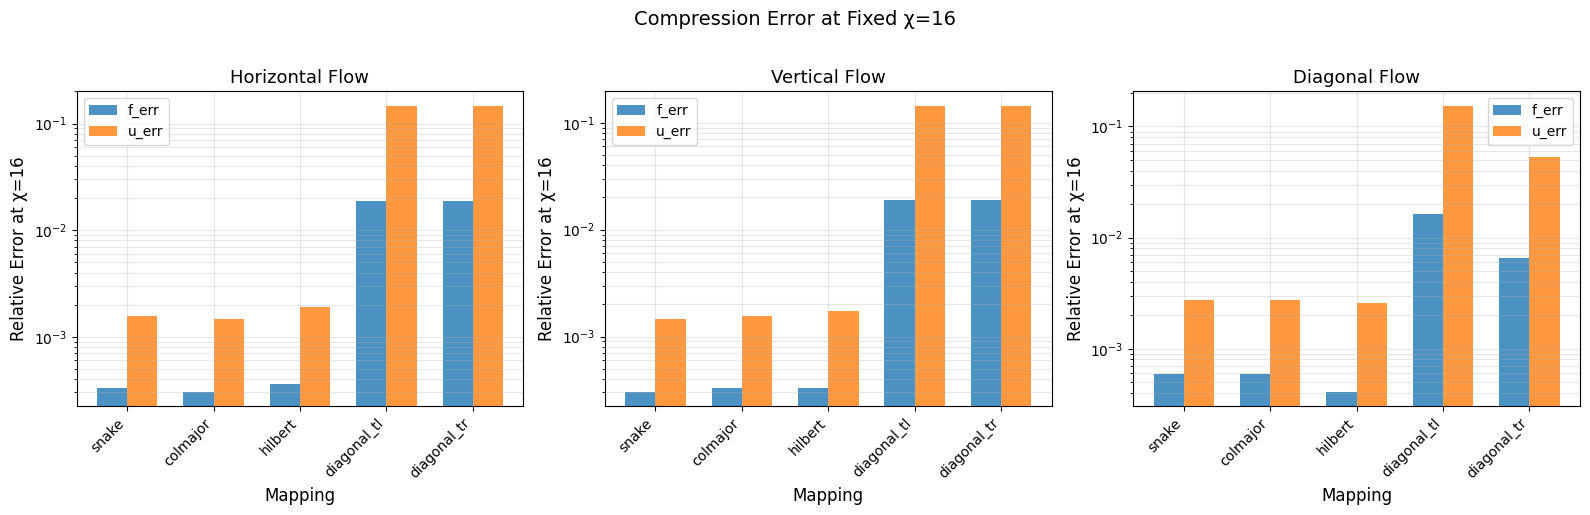

In [30]:
# Visualize errors
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, test_name in zip(axes, test_names):
    f_errs = [errors[(test_name, m)]['f_err'] for m in mappings]
    u_errs = [errors[(test_name, m)]['u_err'] for m in mappings]
    
    x = np.arange(len(mappings))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, f_errs, width, label='f_err', alpha=0.8)
    bars2 = ax.bar(x + width/2, u_errs, width, label='u_err', alpha=0.8)
    
    ax.set_xlabel('Mapping', fontsize=12)
    ax.set_ylabel(f'Relative Error at χ={chi_fixed}', fontsize=12)
    ax.set_title(f'{test_name.capitalize()} Flow', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(mappings, rotation=45, ha='right')
    ax.set_yscale('log')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, which='both')

plt.suptitle(f'Compression Error at Fixed χ={chi_fixed}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Per-Population Bond Dimensions

In [31]:
# Analyze per-population bond dimensions for each test
pop_bonds = {}  # (test_name, pop_idx, mapping) -> chi

print("Per-population natural bond dimensions:\n")
for test_name, (f_test, params) in all_tests.items():
    print(f"\n{test_name.upper()}:")
    print(f"{'Pop':>4} {'Dir':>6} {'snake':>6} {'colmajor':>9} {'hilbert':>8} {'diag_tl':>8} {'diag_tr':>8}")
    print("-" * 60)
    
    for i in range(9):
        bonds = {}
        for mapping in mappings:
            mps, _ = field_to_qtt(f_test[i], max_bond=None, mapping=mapping)
            bonds[mapping] = mps.max_bond()
            pop_bonds[(test_name, i, mapping)] = mps.max_bond()
        
        dir_name = velocity_names[i]
        print(f"{i:>4} {dir_name:>6} {bonds['snake']:>6} {bonds['colmajor']:>9} "
              f"{bonds['hilbert']:>8} {bonds['diagonal_tl']:>8} {bonds['diagonal_tr']:>8}")

Per-population natural bond dimensions:


HORIZONTAL:
 Pop    Dir  snake  colmajor  hilbert  diag_tl  diag_tr
------------------------------------------------------------
   0   Rest     36        31       32      237      237
   1   East     44        37       37      249      248
   2  North     49        49       39      240      235
   3   West     49        43       41      251      250
   4  South     49        49       39      235      240
   5     NE     49        50       37      248      249
   6     NW     56        56       43      250      250
   7     SW     55        56       43      250      251
   8     SE     49        50       38      249      249

VERTICAL:
 Pop    Dir  snake  colmajor  hilbert  diag_tl  diag_tr
------------------------------------------------------------
   0   Rest     31        36       32      237      237
   1   East     49        49       39      239      235
   2  North     37        44       36      249      249
   3   West     49        49 

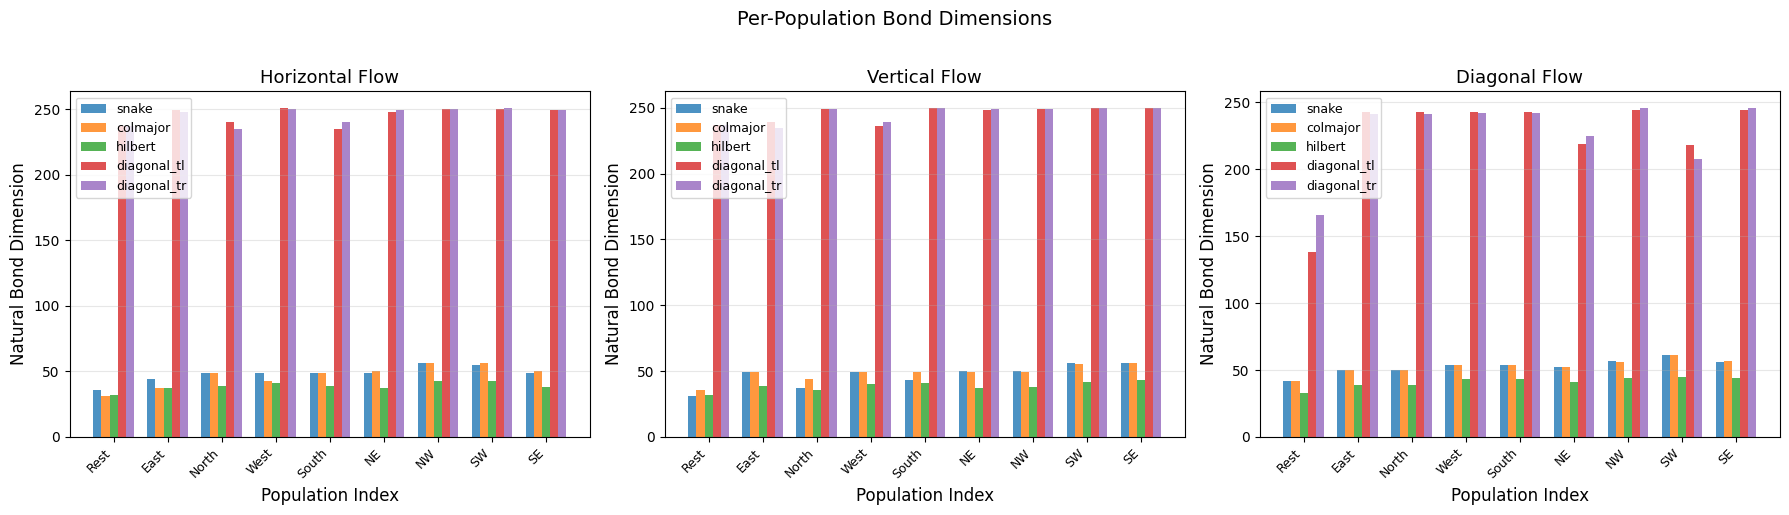

In [32]:
# Visualize per-population chi for each test
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pop_indices = np.arange(9)
width = 0.15

for ax, test_name in zip(axes, test_names):
    for i, mapping in enumerate(mappings):
        chis = [pop_bonds[(test_name, pop, mapping)] for pop in range(9)]
        offset = (i - 2) * width
        ax.bar(pop_indices + offset, chis, width, label=mapping, alpha=0.8)
    
    ax.set_xlabel('Population Index', fontsize=12)
    ax.set_ylabel('Natural Bond Dimension', fontsize=12)
    ax.set_title(f'{test_name.capitalize()} Flow', fontsize=13)
    ax.set_xticks(pop_indices)
    ax.set_xticklabels(velocity_names, rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Per-Population Bond Dimensions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Summary Comparison Table

In [33]:
# Create summary table
print("="*80)
print("SUMMARY: Natural Bond Dimensions (χ_max)")
print("="*80)
print(f"{'Test':>12} {'Snake':>8} {'Colmajor':>10} {'Hilbert':>9} {'Diag_TL':>9} {'Diag_TR':>9} {'Winner':>10}")
print("-"*80)

for test_name in test_names:
    chi_vals = {m: natural_bonds[(test_name, m)]['max'] for m in mappings}
    winner = min(chi_vals, key=chi_vals.get)
    
    print(f"{test_name:>12} {chi_vals['snake']:>8} {chi_vals['colmajor']:>10} "
          f"{chi_vals['hilbert']:>9} {chi_vals['diagonal_tl']:>9} {chi_vals['diagonal_tr']:>9} "
          f"{winner:>10}")

print()
print("="*80)
print("SUMMARY: Velocity Error at χ=16 (u_err)")
print("="*80)
print(f"{'Test':>12} {'Snake':>10} {'Colmajor':>12} {'Hilbert':>11} {'Diag_TL':>11} {'Diag_TR':>11} {'Winner':>10}")
print("-"*80)

for test_name in test_names:
    err_vals = {m: errors[(test_name, m)]['u_err'] for m in mappings}
    winner = min(err_vals, key=err_vals.get)
    
    print(f"{test_name:>12} {err_vals['snake']:>10.2e} {err_vals['colmajor']:>12.2e} "
          f"{err_vals['hilbert']:>11.2e} {err_vals['diagonal_tl']:>11.2e} {err_vals['diagonal_tr']:>11.2e} "
          f"{winner:>10}")

SUMMARY: Natural Bond Dimensions (χ_max)
        Test    Snake   Colmajor   Hilbert   Diag_TL   Diag_TR     Winner
--------------------------------------------------------------------------------
  horizontal       56         56        43       251       251    hilbert
    vertical       56         56        43       250       250    hilbert
    diagonal       61         61        45       244       246    hilbert

SUMMARY: Velocity Error at χ=16 (u_err)
        Test      Snake     Colmajor     Hilbert     Diag_TL     Diag_TR     Winner
--------------------------------------------------------------------------------
  horizontal   1.57e-03     1.47e-03    1.89e-03    1.47e-01    1.47e-01   colmajor
    vertical   1.47e-03     1.57e-03    1.73e-03    1.45e-01    1.44e-01      snake
    diagonal   2.76e-03     2.76e-03    2.59e-03    1.54e-01    5.26e-02    hilbert


## 8. 1D Signal Smoothness Analysis

**Total Variation** (TV): sum of absolute differences between consecutive points.

Analyzing horizontal flow, population 5 (NE)
2D field shape: (256, 256)
2D field range: [0.025346, 0.043689]



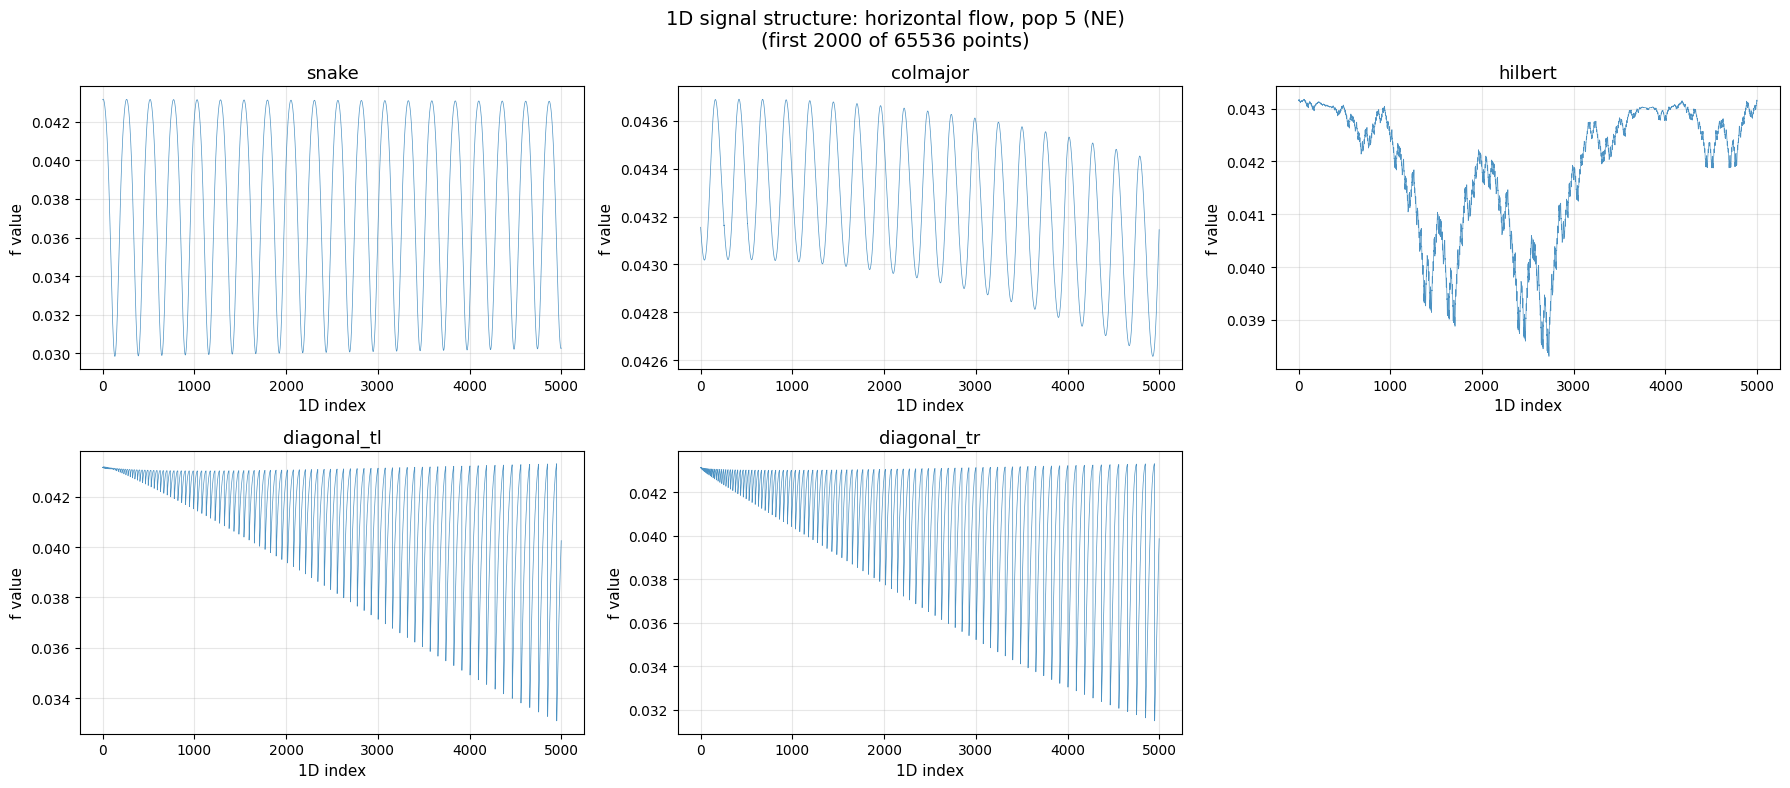

In [41]:
# Analyze 1D signal structure for horizontal flow, population 5 (NE)
# This is the most complex population (diagonal motion)

test_name = 'horizontal'
pop_idx = 5  # NE population
f_test, _ = all_tests[test_name]
field_2d = f_test[pop_idx]

print(f"Analyzing {test_name} flow, population {pop_idx} ({velocity_names[pop_idx]})")
print(f"2D field shape: {field_2d.shape}")
print(f"2D field range: [{field_2d.min():.6f}, {field_2d.max():.6f}]")
print()

# Compute 1D signals for all mappings
signals_1d = {}
for mapping in mappings:
    flat, _ = flatten_2d(field_2d, mapping=mapping)
    signals_1d[mapping] = flat

# Visualize first 5000 points
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, mapping in enumerate(mappings):
    ax = axes[i]
    signal = signals_1d[mapping]
    ax.plot(signal[:5000], linewidth=0.5, alpha=0.8)
    ax.set_title(f'{mapping}', fontsize=13)
    ax.set_xlabel('1D index', fontsize=11)
    ax.set_ylabel('f value', fontsize=11)
    ax.grid(True, alpha=0.3)

axes[-1].axis('off')

plt.suptitle(f'1D signal structure: {test_name} flow, pop {pop_idx} ({velocity_names[pop_idx]})\n(first 2000 of {len(signal)} points)', 
             fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

In [44]:
# Compute smoothness metrics for all mappings
smoothness_metrics = {}

for mapping in mappings:
    signal = signals_1d[mapping]
    
    # Total Variation (TV): sum of absolute consecutive differences
    tv = np.sum(np.abs(np.diff(signal)))
    
    # Mean absolute difference (MAD): average jump between consecutive points
    mad = np.mean(np.abs(np.diff(signal)))
    
    # Max absolute difference: largest jump
    max_diff = np.max(np.abs(np.diff(signal)))
    
    # Gradient L2 norm
    grad_l2 = np.linalg.norm(np.diff(signal))
    
    smoothness_metrics[mapping] = {
        'TV': tv,
        'MAD': mad,
        'max_diff': max_diff,
        'grad_L2': grad_l2
    }

# Print metrics table
print("="*70)
print("1D Signal Smoothness Metrics")
print("="*70)
print(f"{'Mapping':<12} {'TV':>12} {'MAD':>12} {'Max Diff':>12} {'Grad L2':>12}")
print("-"*70)
for mapping in mappings:
    m = smoothness_metrics[mapping]
    print(f"{mapping:<12} {m['TV']:>12.2f} {m['MAD']:>12.6f} {m['max_diff']:>12.6f} {m['grad_L2']:>12.2f}")
print("="*70)

1D Signal Smoothness Metrics
Mapping                TV          MAD     Max Diff      Grad L2
----------------------------------------------------------------------
snake                7.66     0.000117     0.003579         0.04
colmajor             1.75     0.000027     0.001842         0.02
hilbert              4.69     0.000072     0.002453         0.03
diagonal_tl         11.03     0.000168     0.013803         0.18
diagonal_tr         10.93     0.000167     0.013727         0.18


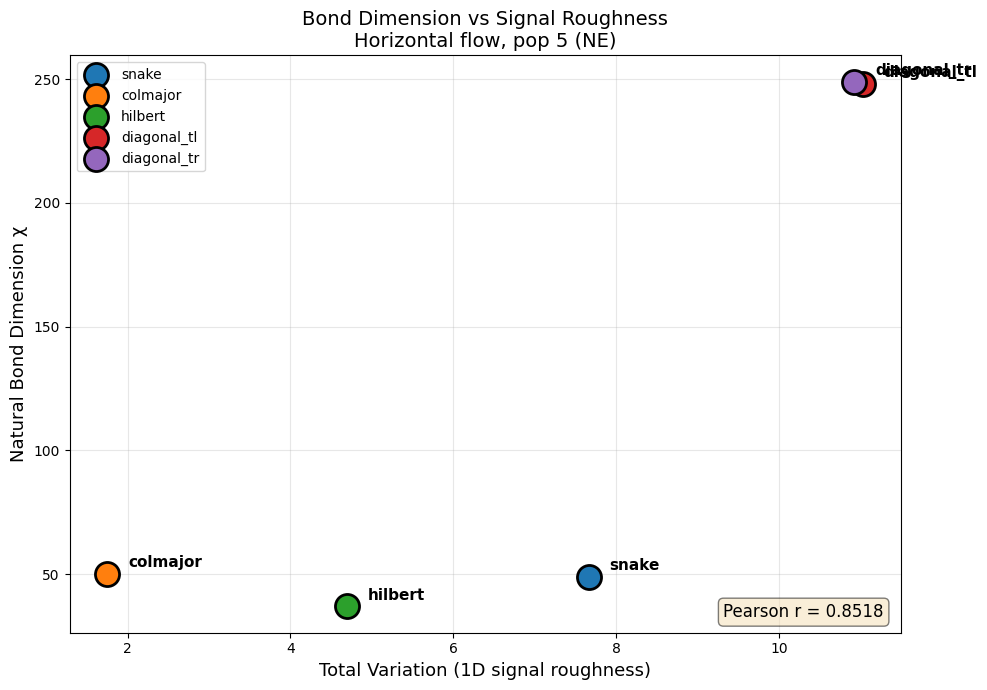

Correlation coefficient (TV vs χ): r = 0.8518


In [46]:
# Visualize correlation: Total Variation vs Natural Bond Dimension
fig, ax = plt.subplots(figsize=(10, 7))

# Get natural bond dim for this specific population
bond_dims = []
total_vars = []
colors_map = {'snake': 'C0', 'colmajor': 'C1', 'hilbert': 'C2', 'diagonal_tl': 'C3', 'diagonal_tr': 'C4'}

for mapping in mappings:
    chi = pop_bonds[(test_name, pop_idx, mapping)]
    tv = smoothness_metrics[mapping]['TV']
    
    bond_dims.append(chi)
    total_vars.append(tv)
    
    # Scatter point
    ax.scatter(tv, chi, s=300, c=colors_map[mapping], 
              edgecolors='black', linewidth=2, zorder=10, label=mapping)
    
    # Annotate
    ax.annotate(mapping, (tv, chi), 
               textcoords="offset points", xytext=(15, 5), 
               fontsize=11, fontweight='bold')

ax.set_xlabel('Total Variation (1D signal roughness)', fontsize=13)
ax.set_ylabel('Natural Bond Dimension χ', fontsize=13)
ax.set_title(f'Bond Dimension vs Signal Roughness\n{test_name.capitalize()} flow, pop {pop_idx} ({velocity_names[pop_idx]})', 
            fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='upper left')

# Compute correlation
corr = np.corrcoef(total_vars, bond_dims)[0, 1]
ax.text(0.98, 0.02, f'Pearson r = {corr:.4f}', 
       transform=ax.transAxes, ha='right', va='bottom',
       fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"Correlation coefficient (TV vs χ): r = {corr:.4f}")

TV vs χ for ALL populations (horizontal flow)


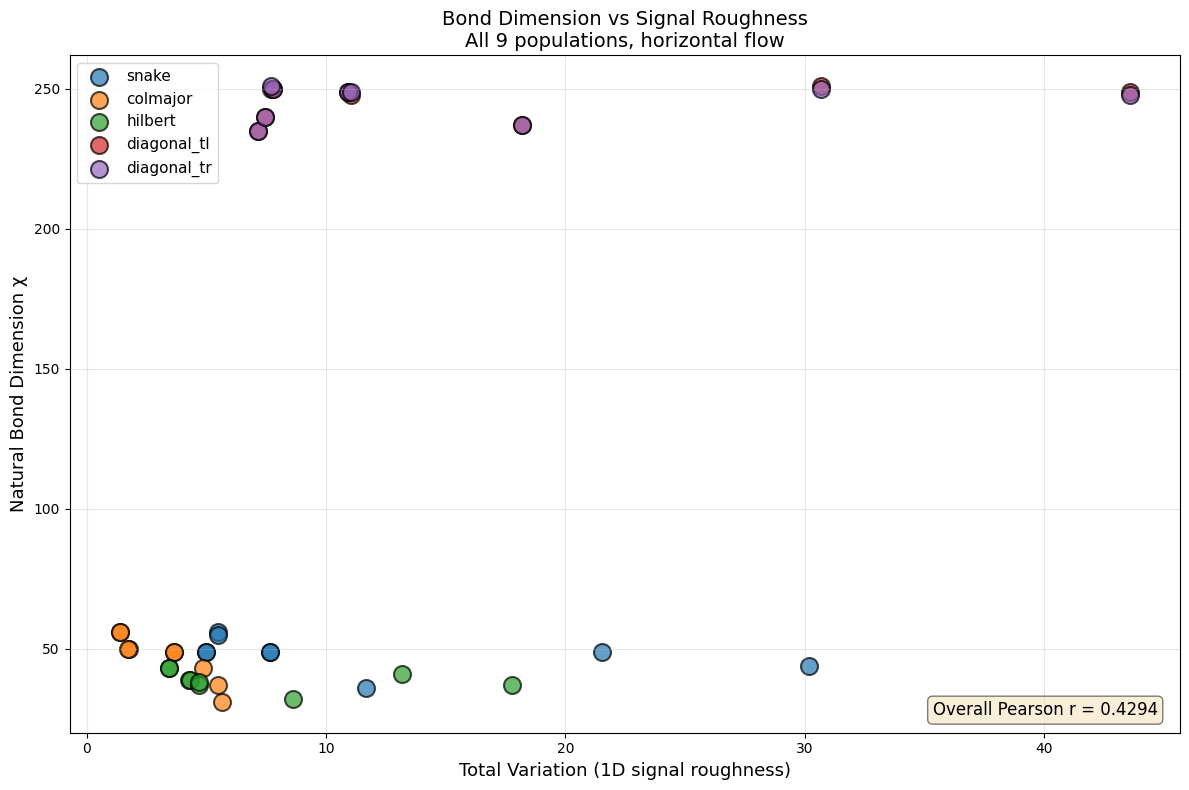

Overall correlation (all pops, all mappings): r = 0.4294


In [47]:
# Compare across all populations for horizontal flow
print("="*80)
print("TV vs χ for ALL populations (horizontal flow)")
print("="*80)

all_pop_data = {mapping: {'TV': [], 'chi': []} for mapping in mappings}

for pop_i in range(9):
    field = f_horizontal[pop_i]
    
    for mapping in mappings:
        flat, _ = flatten_2d(field, mapping=mapping)
        tv = np.sum(np.abs(np.diff(flat)))
        chi = pop_bonds[('horizontal', pop_i, mapping)]
        
        all_pop_data[mapping]['TV'].append(tv)
        all_pop_data[mapping]['chi'].append(chi)

# Scatter plot: all populations, color by mapping
fig, ax = plt.subplots(figsize=(12, 8))

for mapping in mappings:
    tvs = all_pop_data[mapping]['TV']
    chis = all_pop_data[mapping]['chi']
    ax.scatter(tvs, chis, s=150, c=colors_map[mapping], 
              alpha=0.7, edgecolors='black', linewidth=1.5, label=mapping)

ax.set_xlabel('Total Variation (1D signal roughness)', fontsize=13)
ax.set_ylabel('Natural Bond Dimension χ', fontsize=13)
ax.set_title('Bond Dimension vs Signal Roughness\nAll 9 populations, horizontal flow', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper left')

# Overall correlation
all_tvs = []
all_chis = []
for mapping in mappings:
    all_tvs.extend(all_pop_data[mapping]['TV'])
    all_chis.extend(all_pop_data[mapping]['chi'])

corr_all = np.corrcoef(all_tvs, all_chis)[0, 1]
ax.text(0.98, 0.02, f'Overall Pearson r = {corr_all:.4f}', 
       transform=ax.transAxes, ha='right', va='bottom',
       fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"Overall correlation (all pops, all mappings): r = {corr_all:.4f}")

In [49]:
# Final analysis: Why do diagonal mappings create rough signals?
# Visualize the "jumps" in 2D space when traversing the 1D index

from tn.mapping import _diagonal_indices_topleft, _diagonal_indices_topright
from hilbert import decode

def get_mapping_path(n, mapping):
    """Get the 2D coordinates (row, col) for each 1D index."""
    path = np.zeros((n*n, 2), dtype=int)
    
    if mapping == 'snake':
        for i in range(n*n):
            row = i // n
            col = i % n
            path[i] = [row, col]
    
    elif mapping == 'colmajor':
        for i in range(n*n):
            col = i // n
            row = i % n
            path[i] = [row, col]
    
    elif mapping == 'hilbert':
        bits = int(np.log2(n))
        indices = np.arange(n*n, dtype=np.uint64)
        coords = decode(indices, 2, bits)
        path[:, 0] = coords[:, 1]  # row = y
        path[:, 1] = coords[:, 0]  # col = x
    
    elif mapping == 'diagonal_tl':
        coords = _diagonal_indices_topleft(n)
        path[:, 0] = coords[:, 0]  # row = x
        path[:, 1] = coords[:, 1]  # col = y
    
    elif mapping == 'diagonal_tr':
        coords = _diagonal_indices_topright(n)
        path[:, 0] = coords[:, 0]  # row = x
        path[:, 1] = coords[:, 1]  # col = y
    
    return path

# Compute average step distance for each mapping
n_small = 16  # small grid for visualization

print("="*70)
print("Average 2D distance between consecutive 1D indices")
print("="*70)
print(f"{'Mapping':<12} {'Mean dist':>12} {'Max dist':>12} {'% long jumps':>15}")
print("-"*70)

for mapping in mappings:
    path = get_mapping_path(n_small, mapping)
    steps = np.diff(path, axis=0)
    distances = np.sqrt(steps[:, 0]**2 + steps[:, 1]**2)
    
    mean_dist = np.mean(distances)
    max_dist = np.max(distances)
    long_jumps = np.sum(distances > 2.0) / len(distances) * 100
    
    print(f"{mapping:<12} {mean_dist:>12.2f} {max_dist:>12.1f} {long_jumps:>14.1f}%")

print("="*70)

Average 2D distance between consecutive 1D indices
Mapping         Mean dist     Max dist    % long jumps
----------------------------------------------------------------------
snake                1.83         15.0            5.9%
colmajor             1.83         15.0            5.9%
hilbert              1.00          1.0            0.0%
diagonal_tl          2.50         20.5           11.0%
diagonal_tr          2.50         20.5           11.0%


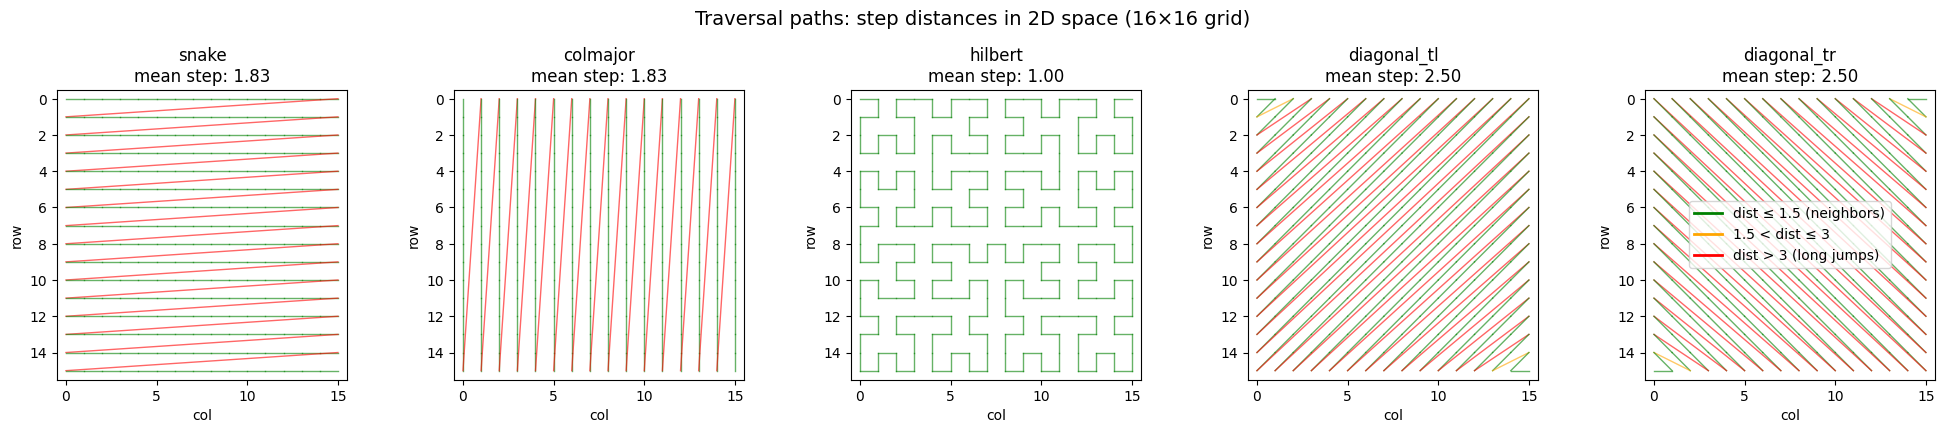

In [51]:
# Visualize the traversal paths with color-coded step distances
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

n_vis = 16

for ax, mapping in zip(axes, mappings):
    path = get_mapping_path(n_vis, mapping)
    steps = np.diff(path, axis=0)
    distances = np.sqrt(steps[:, 0]**2 + steps[:, 1]**2)
    
    # Draw lines colored by distance
    for i in range(len(path)-1):
        r0, c0 = path[i]
        r1, c1 = path[i+1]
        dist = distances[i]
        
        # Color code: green (≤1.5), orange (1.5-3), red (>3)
        if dist <= 1.5:
            color = 'green'
        elif dist <= 3:
            color = 'orange'
        else:
            color = 'red'
        
        ax.plot([c0, c1], [r0, r1], color=color, linewidth=1.0, alpha=0.6)
    
    mean_d = np.mean(distances)
    ax.set_title(f'{mapping}\nmean step: {mean_d:.2f}', fontsize=12)
    ax.set_xlim(-0.5, n_vis-0.5)
    ax.set_ylim(-0.5, n_vis-0.5)
    ax.set_aspect('equal')
    ax.set_xlabel('col', fontsize=10)
    ax.set_ylabel('row', fontsize=10)
    ax.invert_yaxis()  # standard matrix convention

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='green', linewidth=2, label='dist ≤ 1.5 (neighbors)'),
    Line2D([0], [0], color='orange', linewidth=2, label='1.5 < dist ≤ 3'),
    Line2D([0], [0], color='red', linewidth=2, label='dist > 3 (long jumps)')
]
axes[-1].legend(handles=legend_elements, loc='center', fontsize=10, frameon=True)

plt.suptitle(f'Traversal paths: step distances in 2D space ({n_vis}×{n_vis} grid)', 
            fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Transient Analysis: Flow Development

Analyze how compression difficulty changes as the flow develops from rest to steady-state.

**Hypothesis:** Early in the simulation (before vortex shedding), the flow might show stronger directional preferences. As vortices develop, the wake becomes isotropic and mappings converge.

We'll save snapshots at time fractions: 5%, 10%, 20%, 40%, 60%, 80%, 100%

In [52]:
# Modify run_periodic_flow to save snapshots
def run_periodic_flow_with_snapshots(n, Re, direction='horizontal', u_ref=0.1, nt=20000, 
                                     snapshot_fractions=[0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0],
                                     verbose=True):
    """
    Run periodic flow with body force and cylinder obstacle, saving snapshots.
    
    Returns:
        snapshots: List of (t, f) tuples
        params: Simulation parameters
    """
    L = n
    nu = u_ref * L / Re
    tau = 3 * nu + 0.5
    
    if verbose:
        print(f"Direction: {direction}")
        print(f"n={n}, Re={Re}, tau={tau:.4f}")
    
    if tau <= 0.5:
        raise ValueError(f"tau={tau:.4f} <= 0.5, unstable!")
    
    # Create cylinder obstacle in center
    cx = cy = n // 2
    radius = n // 10
    cylinder = create_cylinder_mask(n, n, cx, cy, radius)
    
    if verbose:
        print(f"Cylinder: center=({cx},{cy}), radius={radius}")
    
    # Initialize at rest
    rho = np.ones((n, n))
    u = np.zeros((2, n, n))
    f = compute_equilibrium(D2Q9, rho, u)
    
    # Body force direction
    if direction == 'horizontal':
        force = np.array([1e-5, 0.0])
    elif direction == 'vertical':
        force = np.array([0.0, 1e-5])
    elif direction == 'diagonal':
        f_mag = 1e-5 / np.sqrt(2)
        force = np.array([f_mag, f_mag])
    else:
        raise ValueError(f"Unknown direction: {direction}")
    
    # Compute snapshot times
    snapshot_times = sorted([int(frac * nt) for frac in snapshot_fractions])
    snapshots = []
    
    for t in range(1, nt + 1):
        # Collision with body force
        f = collide_bgk(D2Q9, f, tau)
        
        # Add body force
        for i in range(D2Q9.q):
            cu = D2Q9.c[i, 0] * force[0] + D2Q9.c[i, 1] * force[1]
            f[i] += D2Q9.w[i] * 3.0 * cu
        
        # Streaming (periodic BC automatic)
        f = stream(D2Q9, f)
        
        # Apply bounce-back on cylinder
        f = apply_bounce_back(D2Q9, f, cylinder)
        
        # Save snapshot if needed
        if t in snapshot_times:
            snapshots.append((t, f.copy()))
            if verbose:
                rho_t, u_t = compute_moments(D2Q9, f)
                u_max = np.max(np.sqrt(u_t[0]**2 + u_t[1]**2))
                print(f"  Snapshot t={t}/{nt} ({t/nt*100:.0f}%), u_max={u_max:.4f}")
        
        if np.any(np.isnan(f)):
            print(f"NaN at t={t}!")
            break
    
    return snapshots, {
        'n': n, 'Re': Re, 'tau': tau, 'nu': nu,
        'direction': direction, 'force': force,
        'cylinder': cylinder, 'cylinder_center': (cx, cy), 'cylinder_radius': radius,
        'nt': nt
    }

print("Running simulations with snapshots for transient analysis...")
print("This will take longer than before (saving 7 snapshots per direction)")
print()

Running simulations with snapshots for transient analysis...
This will take longer than before (saving 7 snapshots per direction)



In [53]:
# Run simulations with snapshots
print("="*60)
print("Horizontal Flow (with snapshots)")
print("="*60)
snapshots_h, params_h = run_periodic_flow_with_snapshots(n=256, Re=100, direction='horizontal')
print()

print("="*60)
print("Vertical Flow (with snapshots)")
print("="*60)
snapshots_v, params_v = run_periodic_flow_with_snapshots(n=256, Re=100, direction='vertical')
print()

print("="*60)
print("Diagonal Flow (with snapshots)")
print("="*60)
snapshots_d, params_d = run_periodic_flow_with_snapshots(n=256, Re=100, direction='diagonal')
print()

# Store all transient data
all_transient = {
    'horizontal': (snapshots_h, params_h),
    'vertical': (snapshots_v, params_v),
    'diagonal': (snapshots_d, params_d)
}

print(f"Snapshots saved: {len(snapshots_h)} per direction")
print("Ready for transient compression analysis!")

Horizontal Flow (with snapshots)
Direction: horizontal
n=256, Re=100, tau=1.2680
Cylinder: center=(128,128), radius=25
  Snapshot t=1000/20000 (5%), u_max=0.0126
  Snapshot t=2000/20000 (10%), u_max=0.0238
  Snapshot t=4000/20000 (20%), u_max=0.0449
  Snapshot t=8000/20000 (40%), u_max=0.0809
  Snapshot t=12000/20000 (60%), u_max=0.1145
  Snapshot t=16000/20000 (80%), u_max=0.1422
  Snapshot t=20000/20000 (100%), u_max=0.1648

Vertical Flow (with snapshots)
Direction: vertical
n=256, Re=100, tau=1.2680
Cylinder: center=(128,128), radius=25
  Snapshot t=1000/20000 (5%), u_max=0.0126
  Snapshot t=2000/20000 (10%), u_max=0.0238
  Snapshot t=4000/20000 (20%), u_max=0.0449
  Snapshot t=8000/20000 (40%), u_max=0.0809
  Snapshot t=12000/20000 (60%), u_max=0.1145
  Snapshot t=16000/20000 (80%), u_max=0.1422
  Snapshot t=20000/20000 (100%), u_max=0.1648

Diagonal Flow (with snapshots)
Direction: diagonal
n=256, Re=100, tau=1.2680
Cylinder: center=(128,128), radius=25
  Snapshot t=1000/20000 (5%

In [54]:
# Compute natural bond dimensions for all snapshots
# Only analyze snake, colmajor, and hilbert (skip diagonal mappings - too slow and we know they fail)
transient_mappings = ['snake', 'colmajor', 'hilbert']

natural_bonds_time = {}  # (test_name, mapping, time_frac) -> {'max': chi_max, 'mean': chi_mean}

print("Computing natural bond dimensions for all snapshots...")
print("(This will take several minutes...)")
print()

for test_name, (snapshots, params) in all_transient.items():
    print(f"{test_name.upper()}:")
    for t, f_snap in snapshots:
        time_frac = t / params['nt']
        for mapping in transient_mappings:
            mps_list, _ = compress_populations(f_snap, max_bond=None, mapping=mapping)
            chi_max = max(mps.max_bond() for mps in mps_list)
            chi_mean = np.mean([mps.max_bond() for mps in mps_list])
            natural_bonds_time[(test_name, mapping, time_frac)] = {'max': chi_max, 'mean': chi_mean}
            print(f"  t={t} ({time_frac*100:4.0f}%), {mapping:8s}: chi_max={chi_max:3d}, chi_mean={chi_mean:5.1f}")
    print()

print("Transient compression analysis complete!")

Computing natural bond dimensions for all snapshots...
(This will take several minutes...)

HORIZONTAL:
  t=1000 (   5%), snake   : chi_max= 40, chi_mean= 34.3
  t=1000 (   5%), colmajor: chi_max= 44, chi_mean= 36.2
  t=1000 (   5%), hilbert : chi_max= 30, chi_mean= 26.3
  t=2000 (  10%), snake   : chi_max= 45, chi_mean= 38.2
  t=2000 (  10%), colmajor: chi_max= 47, chi_mean= 39.7
  t=2000 (  10%), hilbert : chi_max= 34, chi_mean= 30.0
  t=4000 (  20%), snake   : chi_max= 48, chi_mean= 41.6
  t=4000 (  20%), colmajor: chi_max= 50, chi_mean= 42.7
  t=4000 (  20%), hilbert : chi_max= 38, chi_mean= 34.0
  t=8000 (  40%), snake   : chi_max= 50, chi_mean= 45.1
  t=8000 (  40%), colmajor: chi_max= 51, chi_mean= 43.9
  t=8000 (  40%), hilbert : chi_max= 40, chi_mean= 36.4
  t=12000 (  60%), snake   : chi_max= 53, chi_mean= 46.9
  t=12000 (  60%), colmajor: chi_max= 53, chi_mean= 44.9
  t=12000 (  60%), hilbert : chi_max= 41, chi_mean= 37.2
  t=16000 (  80%), snake   : chi_max= 54, chi_mean= 4

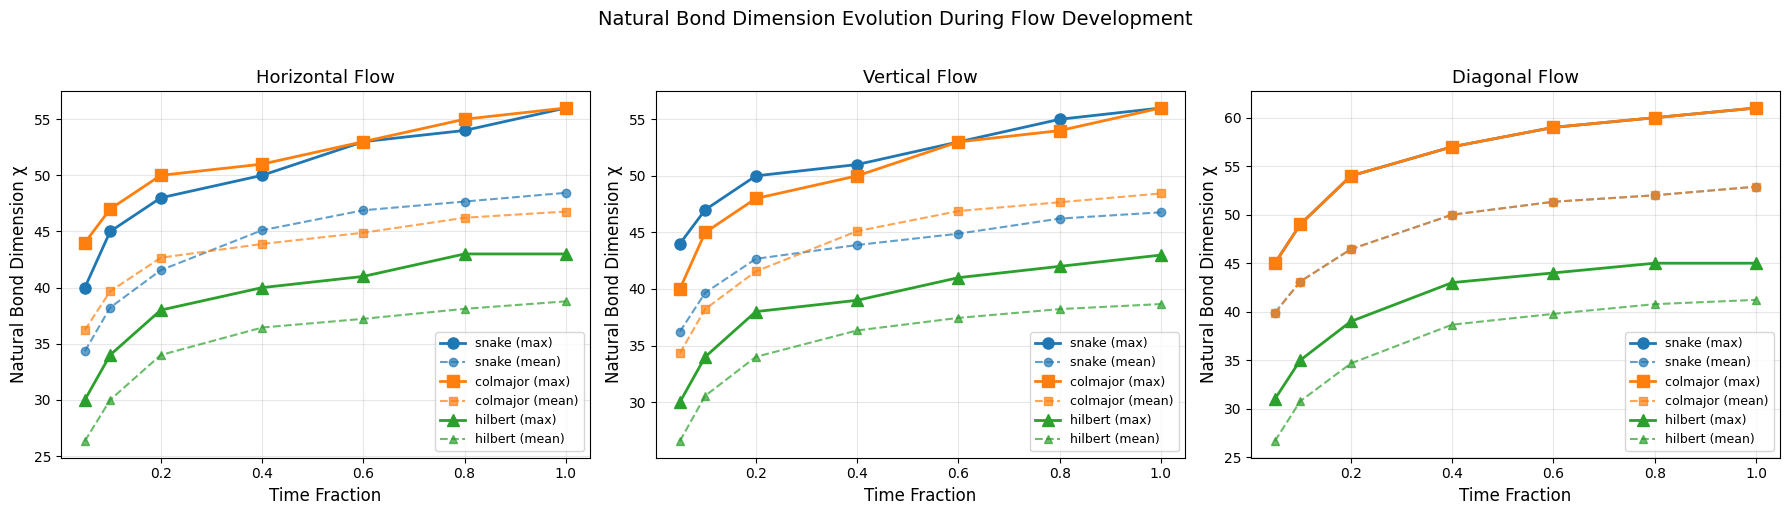

In [55]:
# Plot: Natural bond dimension evolution during flow development
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors_trans = {'snake': 'C0', 'colmajor': 'C1', 'hilbert': 'C2'}
markers_trans = {'snake': 'o', 'colmajor': 's', 'hilbert': '^'}

for ax, test_name in zip(axes, test_names):
    for mapping in transient_mappings:
        fracs = sorted([frac for (tn, m, frac) in natural_bonds_time if tn==test_name and m==mapping])
        chis_max = [natural_bonds_time[(test_name, mapping, frac)]['max'] for frac in fracs]
        chis_mean = [natural_bonds_time[(test_name, mapping, frac)]['mean'] for frac in fracs]
        
        # Plot max bond dim (solid line)
        ax.plot(fracs, chis_max, f'{markers_trans[mapping]}-', 
               color=colors_trans[mapping], label=f'{mapping} (max)', 
               linewidth=2, markersize=8)
        # Plot mean bond dim (dashed line)
        ax.plot(fracs, chis_mean, f'{markers_trans[mapping]}--', 
               color=colors_trans[mapping], label=f'{mapping} (mean)', 
               linewidth=1.5, markersize=6, alpha=0.7)
    
    ax.set_xlabel('Time Fraction', fontsize=12)
    ax.set_ylabel('Natural Bond Dimension χ', fontsize=12)
    ax.set_title(f'{test_name.capitalize()} Flow', fontsize=13)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle('Natural Bond Dimension Evolution During Flow Development', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [57]:
# Find minimum chi required for u_err < 1% at each snapshot
target_u_err = 0.01
chi_test_values = [4, 8, 12, 16, 24, 32, 48, 64, 128]

chi_required_time = {}  # (test_name, mapping, time_frac) -> chi

print(f"Finding minimum χ for u_err < {target_u_err*100:.0f}% at all snapshots...")
print("(This will take several minutes...)")
print()

for test_name, (snapshots, params) in all_transient.items():
    print(f"{test_name.upper()}:")
    for t, f_snap in snapshots:
        time_frac = t / params['nt']
        rho_orig, u_orig = compute_moments(D2Q9, f_snap)
        
        for mapping in transient_mappings:
            for chi in chi_test_values:
                mps_list, meta = compress_populations(f_snap, max_bond=chi, mapping=mapping)
                f_recon = decompress_populations(mps_list, meta)
                _, u_comp = compute_moments(D2Q9, f_recon)
                u_err = np.linalg.norm(u_orig - u_comp) / np.linalg.norm(u_orig)
                
                if u_err < target_u_err:
                    chi_required_time[(test_name, mapping, time_frac)] = chi
                    break
            else:
                chi_required_time[(test_name, mapping, time_frac)] = chi_test_values[-1]
            
            chi_val = chi_required_time[(test_name, mapping, time_frac)]
            print(f"  t={t} ({time_frac*100:4.0f}%), {mapping:8s}: chi_req={chi_val}")
    print()

print("Required chi analysis complete!")

Finding minimum χ for u_err < 1% at all snapshots...
(This will take several minutes...)

HORIZONTAL:
  t=1000 (   5%), snake   : chi_req=8
  t=1000 (   5%), colmajor: chi_req=8
  t=1000 (   5%), hilbert : chi_req=12
  t=2000 (  10%), snake   : chi_req=8
  t=2000 (  10%), colmajor: chi_req=8
  t=2000 (  10%), hilbert : chi_req=12
  t=4000 (  20%), snake   : chi_req=8
  t=4000 (  20%), colmajor: chi_req=8
  t=4000 (  20%), hilbert : chi_req=12
  t=8000 (  40%), snake   : chi_req=8
  t=8000 (  40%), colmajor: chi_req=8
  t=8000 (  40%), hilbert : chi_req=12
  t=12000 (  60%), snake   : chi_req=8
  t=12000 (  60%), colmajor: chi_req=8
  t=12000 (  60%), hilbert : chi_req=12
  t=16000 (  80%), snake   : chi_req=8
  t=16000 (  80%), colmajor: chi_req=8
  t=16000 (  80%), hilbert : chi_req=12
  t=20000 ( 100%), snake   : chi_req=8
  t=20000 ( 100%), colmajor: chi_req=8
  t=20000 ( 100%), hilbert : chi_req=12

VERTICAL:
  t=1000 (   5%), snake   : chi_req=8
  t=1000 (   5%), colmajor: chi_req

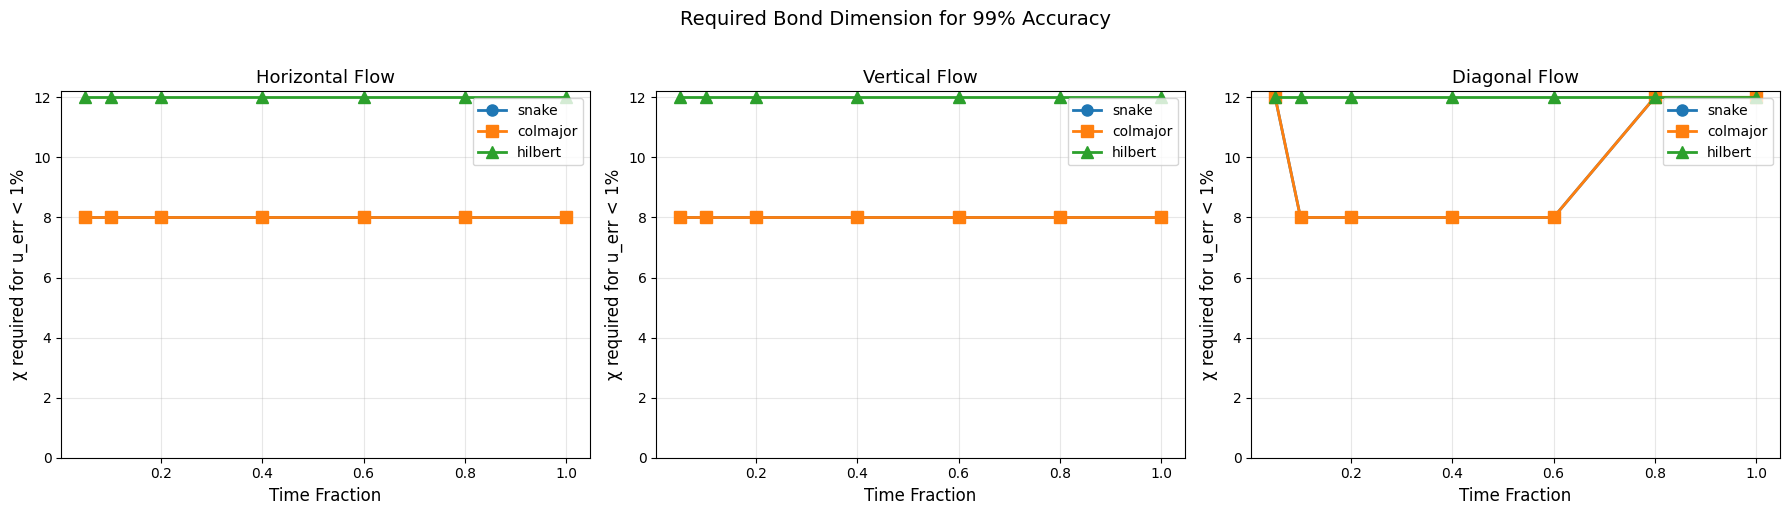

In [58]:
# Plot: Required chi for 99% accuracy during flow development
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, test_name in zip(axes, test_names):
    for mapping in transient_mappings:
        fracs = sorted([frac for (tn, m, frac) in chi_required_time if tn==test_name and m==mapping])
        chis_req = [chi_required_time[(test_name, mapping, frac)] for frac in fracs]
        
        ax.plot(fracs, chis_req, f'{markers_trans[mapping]}-', 
               color=colors_trans[mapping], label=mapping, 
               linewidth=2, markersize=8)
    
    ax.set_xlabel('Time Fraction', fontsize=12)
    ax.set_ylabel(f'χ required for u_err < {target_u_err*100:.0f}%', fontsize=12)
    ax.set_title(f'{test_name.capitalize()} Flow', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

plt.suptitle('Required Bond Dimension for 99% Accuracy', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [59]:
# Summary table: Required chi at key timepoints
print("="*80)
print(f"Required χ for u_err < {target_u_err*100:.0f}% at Key Timepoints")
print("="*80)

for test_name in test_names:
    print(f"\n{test_name.upper()} FLOW:")
    print(f"{'Time %':>8} {'Snake':>8} {'Colmajor':>10} {'Hilbert':>10}")
    print("-"*40)
    
    snapshots_test, params_test = all_transient[test_name]
    for t, _ in snapshots_test:
        frac = t / params_test['nt']
        chi_s = chi_required_time[(test_name, 'snake', frac)]
        chi_c = chi_required_time[(test_name, 'colmajor', frac)]
        chi_h = chi_required_time[(test_name, 'hilbert', frac)]
        print(f"{frac*100:>8.0f} {chi_s:>8} {chi_c:>10} {chi_h:>10}")

print("\n" + "="*80)

Required χ for u_err < 1% at Key Timepoints

HORIZONTAL FLOW:
  Time %    Snake   Colmajor    Hilbert
----------------------------------------
       5        8          8         12
      10        8          8         12
      20        8          8         12
      40        8          8         12
      60        8          8         12
      80        8          8         12
     100        8          8         12

VERTICAL FLOW:
  Time %    Snake   Colmajor    Hilbert
----------------------------------------
       5        8          8         12
      10        8          8         12
      20        8          8         12
      40        8          8         12
      60        8          8         12
      80        8          8         12
     100        8          8         12

DIAGONAL FLOW:
  Time %    Snake   Colmajor    Hilbert
----------------------------------------
       5       12         12         12
      10        8          8         12
      20        8      

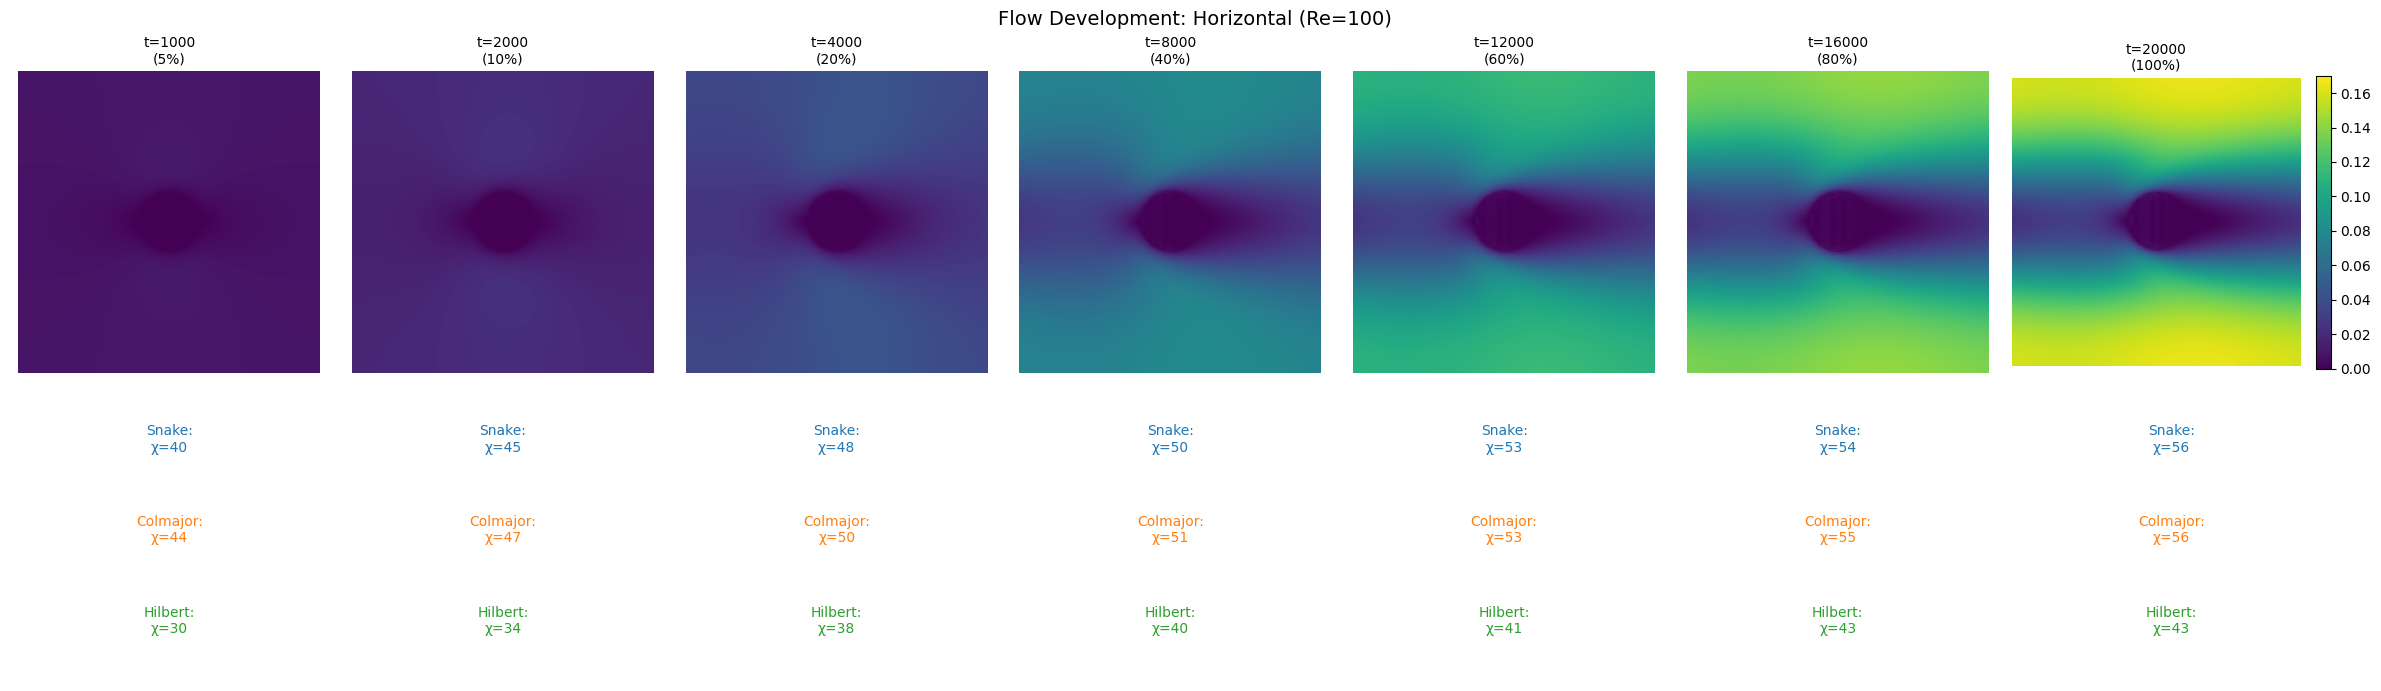

In [56]:
# Visualize flow development for horizontal case
test_show = 'horizontal'
snapshots_show, params_show = all_transient[test_show]

fig, axes = plt.subplots(2, 7, figsize=(24, 7))

for col, (t, f_snap) in enumerate(snapshots_show):
    rho, u = compute_moments(D2Q9, f_snap)
    speed = np.sqrt(u[0]**2 + u[1]**2)
    time_frac = t / params_show['nt']
    
    # Top row: velocity magnitude
    im1 = axes[0, col].imshow(speed.T, cmap='viridis', origin='lower', vmin=0, vmax=0.17)
    axes[0, col].set_title(f't={t}\n({time_frac*100:.0f}%)', fontsize=10)
    axes[0, col].axis('off')
    if col == 6:
        plt.colorbar(im1, ax=axes[0, col], fraction=0.046)
    
    # Bottom row: natural bond dim info
    chi_snake = natural_bonds_time[(test_show, 'snake', time_frac)]['max']
    chi_colmajor = natural_bonds_time[(test_show, 'colmajor', time_frac)]['max']
    chi_hilbert = natural_bonds_time[(test_show, 'hilbert', time_frac)]['max']
    
    axes[1, col].text(0.5, 0.8, f'Snake:\nχ={chi_snake}', 
                      transform=axes[1, col].transAxes, 
                      ha='center', va='center', fontsize=10, color='C0')
    axes[1, col].text(0.5, 0.5, f'Colmajor:\nχ={chi_colmajor}', 
                      transform=axes[1, col].transAxes, 
                      ha='center', va='center', fontsize=10, color='C1')
    axes[1, col].text(0.5, 0.2, f'Hilbert:\nχ={chi_hilbert}', 
                      transform=axes[1, col].transAxes, 
                      ha='center', va='center', fontsize=10, color='C2')
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Velocity\nmagnitude', fontsize=12, rotation=0, labelpad=50, va='center')
axes[1, 0].set_ylabel('Natural\nbond dim', fontsize=12, rotation=0, labelpad=50, va='center')

plt.suptitle(f'Flow Development: {test_show.capitalize()} (Re=100)', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()